In [319]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import  seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraried imported successfully ")

Libraried imported successfully 


# Import Dataset  

In [320]:
df = pd.read_csv("car data.csv")

# Exploring dataset

In [273]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [274]:
# Rows and columns
df.shape

(301, 9)

In [276]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [280]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Missing values Check

In [321]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [322]:
# duplicate values 
print(df.duplicated().sum())

2


In [323]:
# Drop duplicate values
df = df.drop_duplicates()

In [324]:
df.duplicated().sum()

np.int64(0)

# Categorical Values Check

In [325]:
print(df["Fuel_Type"].unique())
print(df["Seller_Type"].unique())
print(df["Transmission"].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


# Feature Engineering 

In [330]:
# Creating new variable and subtract current_year value.
current_year = 2026 

df['Car_Age'] = current_year - df["Year"]

In [332]:
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [335]:
# brand Extraction 
df["Brand"] = df["Car_Name"].str.split().str[0]

In [337]:
df[['Car_Name', 'Brand']].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


In [340]:
X = df.drop(
    ["Selling_Price", "Car_Name", "Year"],
    axis = 1
)

y = df["Selling_Price"]

# EDA

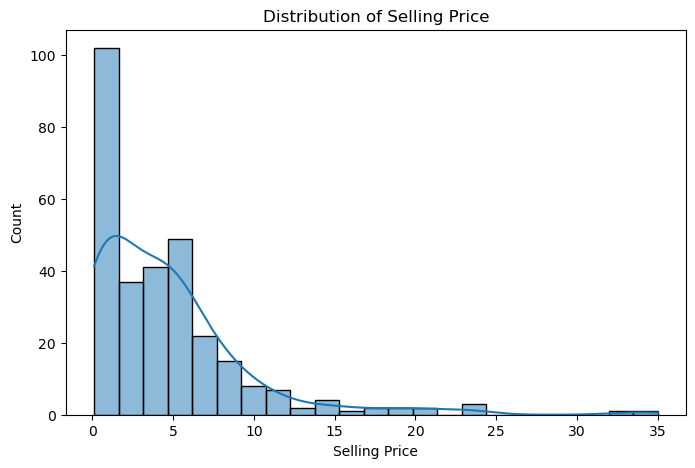

In [302]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

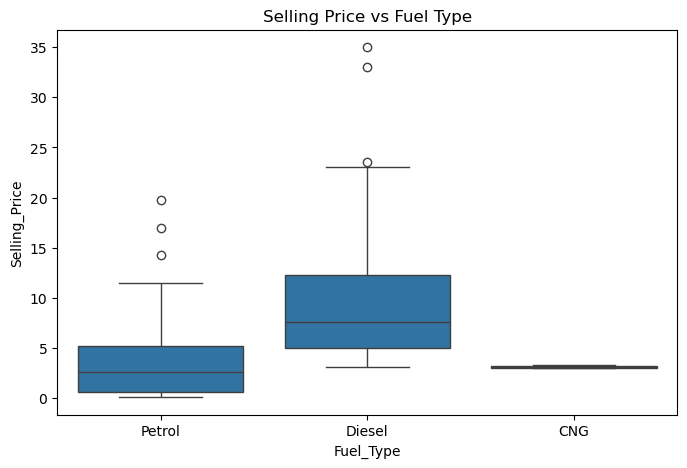

In [303]:
# Price vs fuel type
plt.figure(figsize=(8,5))

sns.boxplot(x="Fuel_Type", y="Selling_Price", data = df)

plt.title("Selling Price vs Fuel Type")
plt.show()

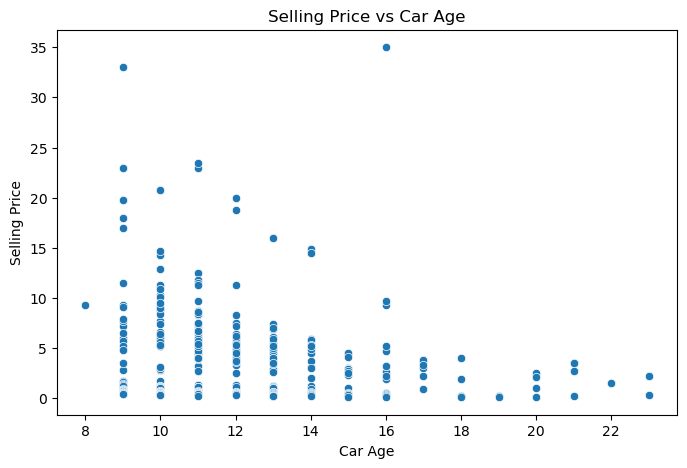

In [304]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df 
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

In [306]:
# Correlation Heatmap
df.select_dtypes(include=np.number).columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner',
       'Car_Age'],
      dtype='object')

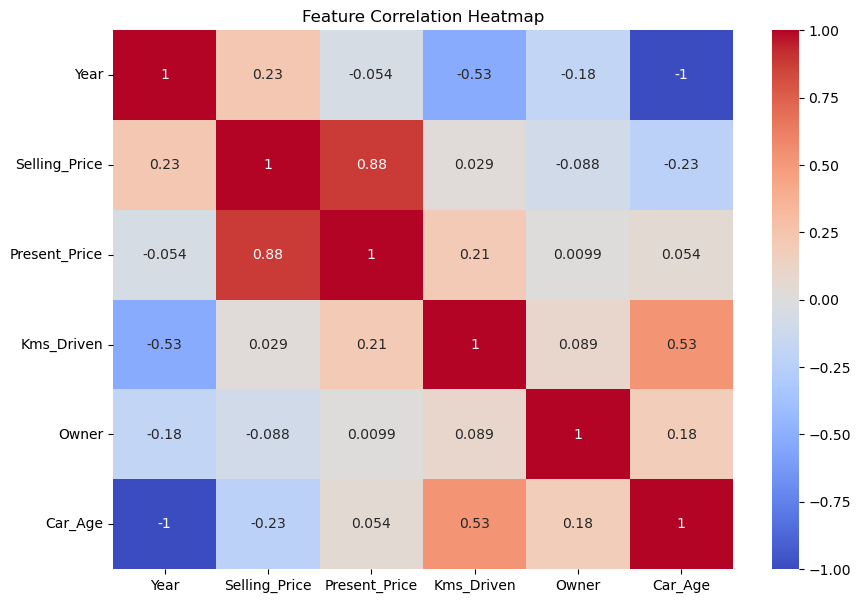

In [309]:
# Correlation Heatmap : Show strong realtion between two numerical variables. 
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# One Hot Encoding of Categorical Variable

In [342]:
# Encoding
X = pd.get_dummies(
    X,
    columns=["Fuel_Type",
             "Seller_Type",
             "Transmission",
             "Brand"
            ],
    drop_first=True
)

In [345]:
print(X.select_dtypes(include="object").columns)


Index([], dtype='object')


In [346]:
print(X.dtypes)

Present_Price             float64
Kms_Driven                  int64
Owner                       int64
Car_Age                     int64
Fuel_Type_Diesel             bool
Fuel_Type_Petrol             bool
Seller_Type_Individual       bool
Transmission_Manual          bool
Brand_Activa                 bool
Brand_Bajaj                  bool
Brand_Hero                   bool
Brand_Honda                  bool
Brand_Hyosung                bool
Brand_KTM                    bool
Brand_Mahindra               bool
Brand_Royal                  bool
Brand_Suzuki                 bool
Brand_TVS                    bool
Brand_UM                     bool
Brand_Yamaha                 bool
Brand_alto                   bool
Brand_amaze                  bool
Brand_baleno                 bool
Brand_brio                   bool
Brand_camry                  bool
Brand_ciaz                   bool
Brand_city                   bool
Brand_corolla                bool
Brand_creta                  bool
Brand_dzire   

# Train test split

In [348]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Model

In [352]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest Regressor


In [355]:
rf_model = RandomForestRegressor  (random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting


In [357]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# Evaluation of model to check model's performance 

In [358]:
# Linear Regression Evaluation 
mae = mean_absolute_error(y_test, y_pred_lr)

# RMSE
rmse =np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

# R^2 Square Score
r2= r2_score(y_test, y_pred_lr)

print(" Linear Regression : ")
print(" mae score: ", mae)
print(" RMSE score: ", rmse)
print(" r2 score: ", r2)

 Linear Regression : 
 mae score:  1.8087830243665026
 RMSE score:  3.3993205771639228
 r2 score:  0.5516523951567611


# Random Forest 3 metrics

In [359]:
# Random Forest Evaluotion 
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)


print(" Random Forest : ")
print(" mae score: ", mae_rf)
print(" RMSE score: ", rmse_rf)
print(" r2 score: ", r2_rf)

 Random Forest : 
 mae score:  1.3971300000000004
 RMSE score:  3.3952814271672187
 r2 score:  0.5527172357821646


In [360]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("mae:", mae_gb)
print("RMSE:", rmse_gb)
print("R2:", r2_gb)

Gradient Boosting
MAE: 1.1638474393321807
RMSE: 2.778928028633426
R²: 0.7003700609670584


# Feature importance chart best performing-model 

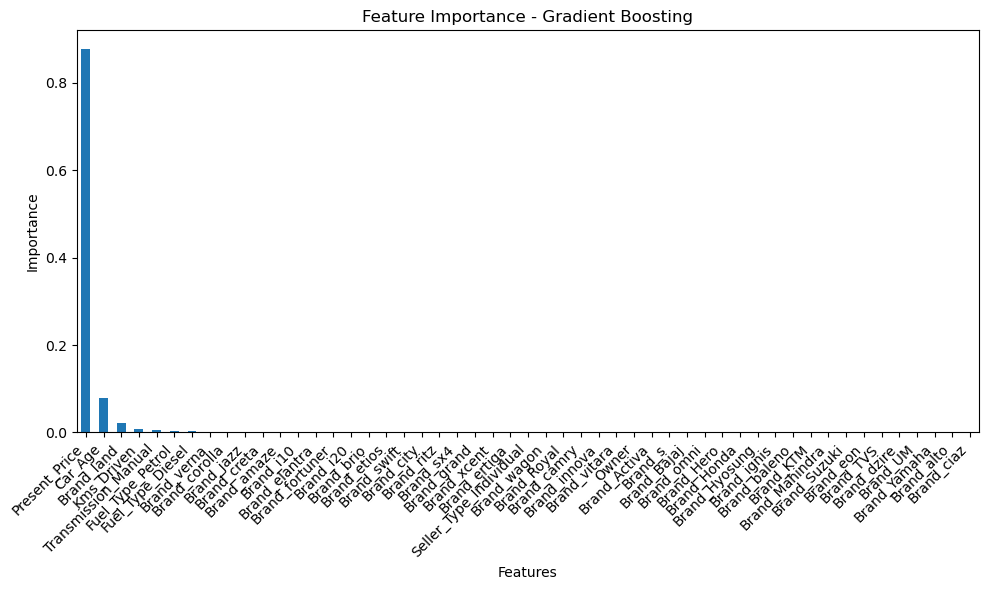

In [361]:
# Gradient Boosting Regressor
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

feature_importance.plot(kind="bar")

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

# Best-performing-#model 
# Gradient Boosting Regressor was slected as the best-performing model because it achieved the lowest MAE and RMSE and the highest R2 score among the evaluated models, Its R squared score of approximately 0.70 indicate that the model exaplains about variation in used car selling prices on the test set 